# 14 — UKB-PPP ST7 Disease-Association Validation

External validation of Liver PC rankings against Sun et al. 2023 UKB-PPP ST7 ALT/AST plasma proteomics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import hypergeom, spearmanr

from trace_path.config import Config
Config.ensure_dirs()

ST7_FILE = Config.RAW_DIR / "41586_2023_6592_MOESM3_ESM.xlsx"
IMP_FILE = Config.TABLES_DIR / "pc_gene_importance_full.csv"

## 14.1 — Load and parse ST7

Two-row header (rows 3-4); flatten to `<condition>|<sub>`. The `log10(p)` column actually carries `−log10(p)` (Bonferroni threshold 4.77 ↔ p < 1.7×10⁻⁵).

In [2]:
import re

raw = pd.read_excel(ST7_FILE, sheet_name='ST7', header=None)
top, sub = raw.iloc[3].ffill(), raw.iloc[4]
_PREFIX = re.compile(r'^[A-Z][0-9]{1,3}[A-Z0-9]?_')

def _flatten(t, s):
    t = '' if pd.isna(t) else str(t).strip()
    s = '' if pd.isna(s) else str(s).strip()
    if not s: return t
    if not t: return s
    return f"{t}|{_PREFIX.sub('', s)}"

st7 = raw.iloc[5:].copy()
st7.columns = [_flatten(t, s) for t, s in zip(top, sub)]
st7 = st7.reset_index(drop=True)
st7['gene_symbol'] = st7['UKBPPP ProteinID'].astype(str).str.split(':').str[0]
for c in [c for c in st7.columns if '|' in c]:
    st7[c] = pd.to_numeric(st7[c], errors='coerce')

print(f"ST7 panel: {len(st7)} proteins, {st7['gene_symbol'].nunique()} unique symbols")

ST7 panel: 2941 proteins, 2922 unique symbols


## 14.2 — Panel-level baseline

In [3]:
SIG_LOG10P = -np.log10(1.7e-5)
ALT_COL, AST_COL = 'ALT (liver function)|log10(p)', 'AST (liver function)|log10(p)'
ALT_BETA, AST_BETA = 'ALT (liver function)|BETA', 'AST (liver function)|BETA'

alt_sig, ast_sig = st7[ALT_COL] >= SIG_LOG10P, st7[AST_COL] >= SIG_LOG10P
print(f"Full panel ({len(st7)}): ALT-sig {alt_sig.sum()} ({100*alt_sig.mean():.0f}%) | AST-sig {ast_sig.sum()} ({100*ast_sig.mean():.0f}%) | either {(alt_sig|ast_sig).sum()} | both {(alt_sig&ast_sig).sum()}")

Full panel (2941): ALT-sig 2035 (69%) | AST-sig 1862 (63%) | either 2294 | both 1603


## 14.3 — Universe (PC ∩ Olink)

20K PC ranking ∩ 2,923 Olink symbols → 2,353 genes. Original PC ranks preserved (`rank_original`); reranked within the universe as `rank_olink`.

In [4]:
imp = pd.read_csv(IMP_FILE)
liv = imp[(imp.tissue == 'Liver') & (imp.category == 'cirrhosis')].sort_values('importance', ascending=False).reset_index(drop=True)
olink_symbols = set(st7['gene_symbol'].dropna().unique())
universe = liv[liv['gene_name'].isin(olink_symbols)].copy().reset_index(drop=True)
universe = universe.rename(columns={'rank': 'rank_original'})
universe.insert(universe.columns.get_loc('rank_original') + 1, 'rank_olink', range(1, len(universe) + 1))

print(f"PC ranking: {len(liv):,}  |  Olink: {len(olink_symbols):,}  |  Universe: {len(universe):,}  (orig ranks {int(universe['rank_original'].min())}–{int(universe['rank_original'].max())})")
print(universe.head(15)[['rank_olink', 'rank_original', 'gene_name', 'importance']].to_string(index=False))

PC ranking: 16,751  |  Olink: 2,922  |  Universe: 2,353  (orig ranks 10–16735)
 rank_olink  rank_original gene_name  importance
          1             10     BMP10    0.000112
          2             12      CHGB    0.000112
          3             15       HBZ    0.000111
          4             17       GAL    0.000110
          5             28     PRDX6    0.000107
          6             43     REG3A    0.000106
          7             44    LGALS3    0.000106
          8             52      MSMB    0.000105
          9             58       PRL    0.000104
         10             64      DLK1    0.000103
         11             79       GH1    0.000102
         12            105     FAM3B    0.000100
         13            133   CD300LG    0.000099
         14            150      LIPF    0.000098
         15            153  PHOSPHO1    0.000098


## 14.4 — Attach ST7 ALT/AST + universe baseline

In [5]:
st7_lookup = (st7[['gene_symbol', 'Protein name', ALT_BETA, ALT_COL, AST_BETA, AST_COL]]
              .assign(_s=lambda d: d[[ALT_COL, AST_COL]].max(axis=1))
              .sort_values('_s', ascending=False).drop_duplicates('gene_symbol').drop(columns='_s'))
universe = universe.rename(columns={'gene_name': 'gene_symbol'}).merge(st7_lookup, on='gene_symbol', how='left')
universe['sig_ALT'], universe['sig_AST'] = universe[ALT_COL] >= SIG_LOG10P, universe[AST_COL] >= SIG_LOG10P
universe['sig_either'], universe['sig_both'] = universe['sig_ALT'] | universe['sig_AST'], universe['sig_ALT'] & universe['sig_AST']

M = len(universe)
K_alt, K_ast = int(universe['sig_ALT'].sum()), int(universe['sig_AST'].sum())
K_either, K_both = int(universe['sig_either'].sum()), int(universe['sig_both'].sum())
print(f"M = {M}  |  ALT-sig K = {K_alt} ({100*K_alt/M:.0f}%)  |  AST-sig K = {K_ast} ({100*K_ast/M:.0f}%)  |  either {K_either}  |  both {K_both}\n")

print(universe[['rank_olink', 'rank_original', 'gene_symbol', 'importance',
                ALT_BETA, ALT_COL, AST_BETA, AST_COL]].head(15)
      .to_string(index=False, float_format=lambda x: f"{x:.3g}"))

M = 2353  |  ALT-sig K = 1701 (72%)  |  AST-sig K = 1504 (64%)  |  either 1890  |  both 1315

 rank_olink  rank_original gene_symbol  importance  ALT (liver function)|BETA  ALT (liver function)|log10(p)  AST (liver function)|BETA  AST (liver function)|log10(p)
          1             10       BMP10    0.000112                     0.0669                           45.9                       0.15                            255
          2             12        CHGB    0.000112                    -0.0407                           17.8                     0.0151                           3.24
          3             15         HBZ    0.000111                     0.0295                           8.68                     0.0233                           6.29
          4             17         GAL     0.00011                     -0.024                           6.47                    -0.0471                           25.5
          5             28       PRDX6    0.000107                    -

## 14.5 — Global Spearman

In [6]:
for col, name in [(ALT_COL, 'ALT -log10p'), (AST_COL, 'AST -log10p'),
                  (ALT_BETA, 'ALT |BETA|'), (AST_BETA, 'AST |BETA|')]:
    vals = universe[col].abs() if 'BETA' in name else universe[col]
    rho, p = spearmanr(universe['importance'], vals)
    print(f"  PC importance vs {name:<14}  ρ = {rho:+.4f}   p = {p:.2e}")

  PC importance vs ALT -log10p     ρ = +0.0673   p = 1.08e-03
  PC importance vs AST -log10p     ρ = +0.1853   p = 1.27e-19
  PC importance vs ALT |BETA|      ρ = +0.0597   p = 3.76e-03
  PC importance vs AST |BETA|      ρ = +0.1799   p = 1.47e-18


## 14.6 — Top-50 candidate heatmap

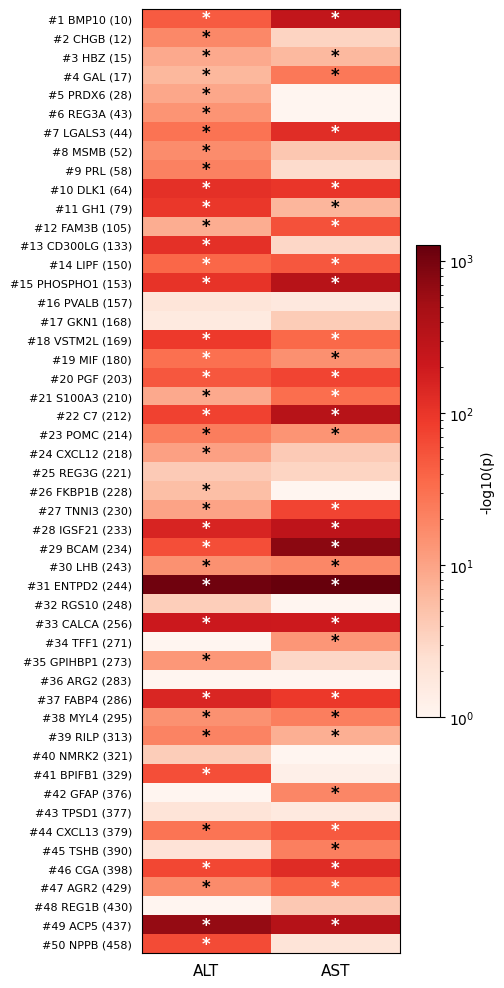

In [7]:
from matplotlib.colors import LogNorm
panel = universe.head(50).reset_index(drop=True)
mat = np.clip(panel[[ALT_COL, AST_COL]].values, 1, None)

fig, ax = plt.subplots(figsize=(5, 10))
im = ax.imshow(mat, aspect='auto', cmap='Reds', norm=LogNorm(vmin=1, vmax=mat.max()))
ax.set_xticks([0, 1]); ax.set_xticklabels(['ALT', 'AST'], fontsize=11)
ax.set_yticks(range(50))
ax.set_yticklabels([f"#{int(r.rank_olink)} {r.gene_symbol} ({int(r.rank_original)})"
                    for _, r in panel.iterrows()], fontsize=8)
for i in range(50):
    for j, c in enumerate([ALT_COL, AST_COL]):
        if panel.iloc[i][c] >= SIG_LOG10P:
            ax.text(j, i, '*', ha='center', va='center',
                    color='white' if mat[i,j] > 30 else 'black', fontsize=12, fontweight='bold')
fig.colorbar(im, ax=ax, shrink=0.5, label='-log10(p)')
ax.tick_params(top=False, bottom=False, left=False)
fig.tight_layout(); fig.savefig(Config.FIGURES_DIR / 'ukbpp_liver_cirrhosis_per_gene.pdf', bbox_inches='tight'); plt.show()

## 14.7 — Save outputs

In [8]:
out = universe.rename(columns={ALT_BETA: 'ALT_BETA', ALT_COL: 'ALT_neg_log10p',
                                AST_BETA: 'AST_BETA', AST_COL: 'AST_neg_log10p'})
T = Config.TABLES_DIR
out.to_csv(T / 'ukbpp_liver_cirrhosis_universe.csv', index=False)
out.head(50).to_csv(T / 'ukbpp_liver_cirrhosis_top50_shortlist.csv', index=False)
out.head(100).to_csv(T / 'ukbpp_liver_cirrhosis_top100_shortlist.csv', index=False)
print("Saved: universe.csv, top50/100_shortlist.csv, gsea_absbeta.pdf, per_gene.pdf")

Saved: universe.csv, top50/100_shortlist.csv, gsea_absbeta.pdf, per_gene.pdf


## 14.8 — Tissue-DE concordance (mean FC, k-fold)

Do genes most differentially expressed between cirrhosis donors and the rest align with UKB-PPP plasma ALT direction?

In [9]:
from sklearn.model_selection import StratifiedKFold
from trace_path.data import load_cache
from trace_path.labels import assign_donor_labels

X_wb, blood_subjid, _, df_meta_url, _ = load_cache()
y, *_ = assign_donor_labels(df_meta_url, 'Liver', 'cirrhosis', blood_subjid)
keep = y.notna()
gids = universe['gene_id'].values
X, y = X_wb.loc[keep, gids], y.loc[keep].astype(int)
print(f"Liver-labelled donors: n={len(y)} ({int(y.sum())} cirrhosis / {int((y==0).sum())} rest)")

skf = StratifiedKFold(n_splits=Config.N_SPLITS, shuffle=True, random_state=Config.SEED)
fc_k = np.zeros((Config.N_SPLITS, len(gids)))
for k, (tr, _) in enumerate(skf.split(X, y)):
    Xt, yt = X.iloc[tr], y.iloc[tr]
    fc_k[k] = ((Xt[yt == 1].mean(axis=0).values + 1) /
               (Xt[yt == 0].mean(axis=0).values + 1))

fc = pd.DataFrame({
    'gene_id':     gids,
    'gene_symbol': universe['gene_symbol'].values,
    'ALT_BETA':    universe[ALT_BETA].values,
    'fc':          np.mean(fc_k, axis=0),
})
fc['fc_rank'] = fc['fc'].rank(method='first', ascending=False).astype(int)
fc.sort_values('fc_rank').to_csv(Config.TABLES_DIR / 'ukbpp_liver_cirrhosis_fc.csv', index=False)
print('\nTop-5 UP in cirrhosis:'); print(fc.nlargest(5, 'fc')[['gene_symbol', 'fc']].to_string(index=False))
print('\nTop-5 DOWN in cirrhosis:'); print(fc.nsmallest(5, 'fc')[['gene_symbol', 'fc']].to_string(index=False))


Loaded cache from /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/TRACE/data/cache/processed_data.pkl
  X_wb: 803 samples × 59033 genes
Liver-labelled donors: n=435 (49 cirrhosis / 386 rest)

Top-5 UP in cirrhosis:
gene_symbol       fc
      FABP4 2.247450
        CA1 2.046433
     ADIPOQ 1.908094
       AHSP 1.850109
      TIMP3 1.654878

Top-5 DOWN in cirrhosis:
gene_symbol       fc
      APOA2 0.080273
        TTR 0.102949
       APOH 0.108026
      APOC1 0.132815
      FABP1 0.146767


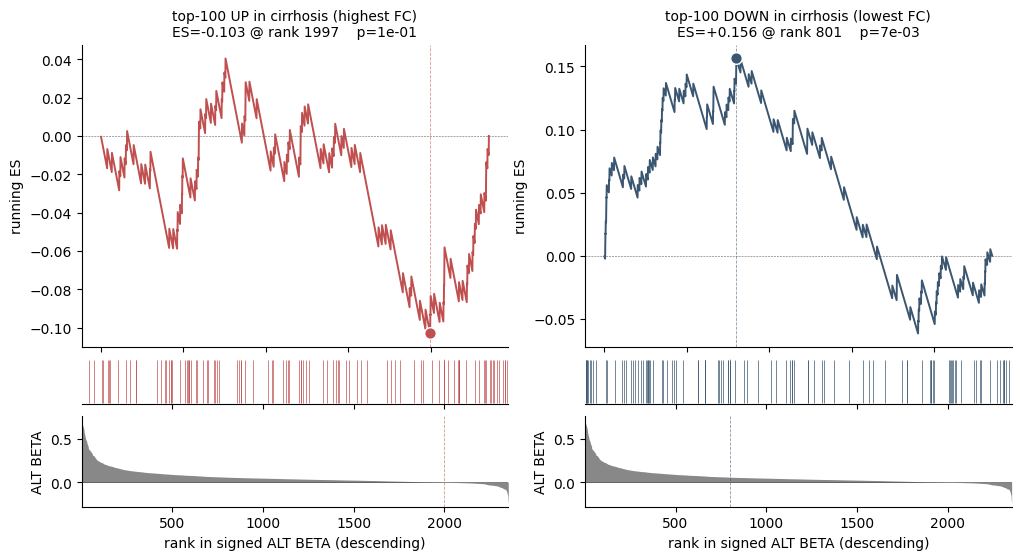

UP-set:   ES=-0.103  peak=1997  p=1e-01
DOWN-set: ES=+0.156  peak=801  p=7e-03


In [10]:
order = np.argsort(-fc['ALT_BETA'].values)
beta_sorted_ids   = fc['gene_id'].values[order]
beta_sorted_betas = fc['ALT_BETA'].values[order]
top_up   = set(fc.nlargest(100,  'fc')['gene_id'])
top_down = set(fc.nsmallest(100, 'fc')['gene_id'])

def gsea_signed(set_ids, ordered_ids, n_perm=2000, seed=0):
    rng = np.random.default_rng(seed)
    hit = np.array([g in set_ids for g in ordered_ids])
    nh, n = hit.sum(), len(hit); h, m = 1/nh, -1/(n-nh)
    rs = np.cumsum(np.where(hit, h, m))
    null = np.array([(lambda x: (x.max(), x.min()))(np.cumsum(np.where(rng.permutation(hit), h, m))) for _ in range(n_perm)])
    es_p, es_n = rs.max(), rs.min()
    if abs(es_p) >= abs(es_n):
        es, peak, pval = es_p, int(rs.argmax()), (null[:, 0] >= es_p).mean()
    else:
        es, peak, pval = es_n, int(rs.argmin()), (null[:, 1] <= es_n).mean()
    return dict(rs=rs, hit=hit, es=es, peak=peak, p=pval)

r_up   = gsea_signed(top_up,   beta_sorted_ids)
r_down = gsea_signed(top_down, beta_sorted_ids)

fig = plt.figure(figsize=(12, 6))
outer = fig.add_gridspec(1, 2, wspace=0.18)

for col, (r, lbl, c) in enumerate([(r_up,   'top-100 UP in cirrhosis (highest FC)',   '#C04F4F'),
                                    (r_down, 'top-100 DOWN in cirrhosis (lowest FC)', '#3A5670')]):
    inner = outer[col].subgridspec(3, 1, height_ratios=[4, 0.6, 1.2], hspace=0.08)
    ax1, ax2, ax3 = (fig.add_subplot(inner[i]) for i in range(3))
    x = np.arange(1, len(r['rs']) + 1)

    ax1.plot(x, r['rs'], color=c, lw=1.4)
    ax1.axhline(0, color='#666', lw=0.4, ls='--')
    ax1.scatter(r['peak'] + 1, r['es'], color=c, s=70, edgecolor='white', zorder=3)
    ax1.axvline(r['peak'] + 1, color=c, ls='--', lw=0.6, alpha=0.6)
    ax1.set_title(f"{lbl}\nES={r['es']:+.3f} @ rank {r['peak']+1}    p={r['p']:.0e}", fontsize=10)
    ax1.set_ylabel('running ES')
    ax1.tick_params(labelbottom=False)
    ax1.spines[['top', 'right']].set_visible(False)

    ax2.eventplot([np.where(r['hit'])[0] + 1], colors=[c], lineoffsets=[0.5], linelengths=[0.95], linewidths=0.5)
    ax2.axvline(r['peak'] + 1, color=c, ls='--', lw=0.6, alpha=0.6)
    ax2.set_xlim(1, len(x)); ax2.set_ylim(0, 1)
    ax2.set_yticks([]); ax2.tick_params(labelbottom=False, left=False)
    ax2.spines[['top', 'right', 'left']].set_visible(False)

    ax3.fill_between(x, 0, beta_sorted_betas, color='#888', lw=0)
    ax3.axhline(0, color='#333', lw=0.4)
    ax3.axvline(r['peak'] + 1, color=c, ls='--', lw=0.6, alpha=0.6)
    ax3.set_xlim(1, len(x))
    ax3.set_xlabel('rank in signed ALT BETA (descending)')
    ax3.set_ylabel('ALT BETA')
    ax3.spines[['top', 'right']].set_visible(False)

fig.savefig(Config.FIGURES_DIR / 'ukbpp_liver_cirrhosis_fc_concordance.pdf', bbox_inches='tight')
plt.show()
print(f"UP-set:   ES={r_up['es']:+.3f}  peak={r_up['peak']+1}  p={r_up['p']:.0e}")
print(f"DOWN-set: ES={r_down['es']:+.3f}  peak={r_down['peak']+1}  p={r_down['p']:.0e}")


## 14.9 — FC concordance with sign(BETA) × −log10(p) ranking

Same as §14.8 but ranking weights BETA by statistical confidence via sign(BETA) × −log10(p).

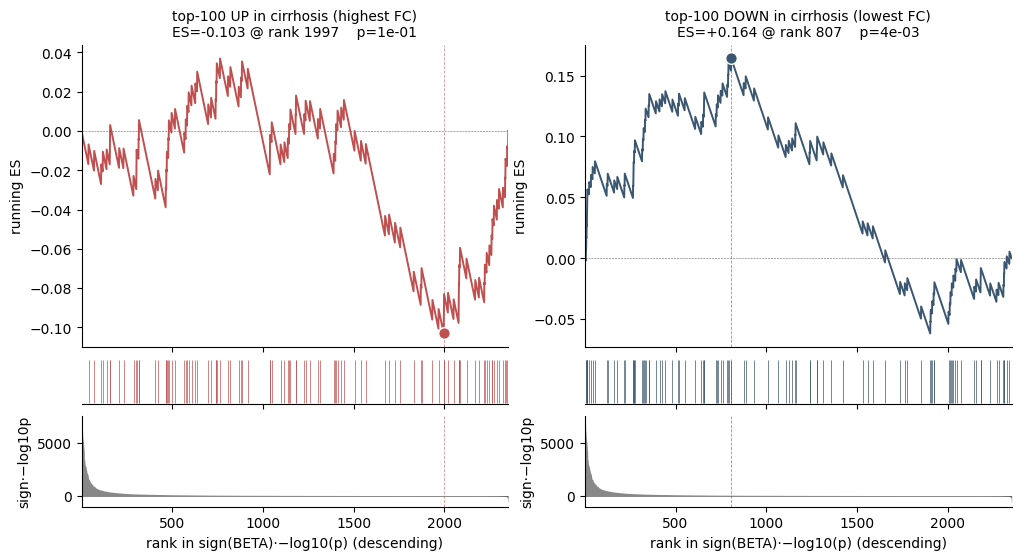

UP-set:   ES=-0.103  peak=1997  p=1e-01
DOWN-set: ES=+0.164  peak=807  p=4e-03


In [11]:
# Ranking metric = sign(BETA) × −log10(p)
metric = np.sign(universe[ALT_BETA].values) * universe[ALT_COL].values
order2 = np.argsort(-metric)
metric_sorted_ids   = fc['gene_id'].values[order2]
metric_sorted_vals  = metric[order2]

r_up2   = gsea_signed(top_up,   metric_sorted_ids)
r_down2 = gsea_signed(top_down, metric_sorted_ids)

fig = plt.figure(figsize=(12, 6))
outer = fig.add_gridspec(1, 2, wspace=0.18)
for col, (r, lbl, c) in enumerate([(r_up2,   'top-100 UP in cirrhosis (highest FC)',   '#C04F4F'),
                                    (r_down2, 'top-100 DOWN in cirrhosis (lowest FC)', '#3A5670')]):
    inner = outer[col].subgridspec(3, 1, height_ratios=[4, 0.6, 1.2], hspace=0.08)
    ax1, ax2, ax3 = (fig.add_subplot(inner[i]) for i in range(3))
    x = np.arange(1, len(r['rs']) + 1)
    ax1.plot(x, r['rs'], color=c, lw=1.4)
    ax1.axhline(0, color='#666', lw=0.4, ls='--')
    ax1.scatter(r['peak'] + 1, r['es'], color=c, s=70, edgecolor='white', zorder=3)
    ax1.axvline(r['peak'] + 1, color=c, ls='--', lw=0.6, alpha=0.6)
    ax1.set_xlim(1, len(x))
    ax1.set_title(f"{lbl}\nES={r['es']:+.3f} @ rank {r['peak']+1}    p={r['p']:.0e}", fontsize=10)
    ax1.set_ylabel('running ES'); ax1.tick_params(labelbottom=False)
    ax1.spines[['top', 'right']].set_visible(False)
    ax2.eventplot([np.where(r['hit'])[0] + 1], colors=[c], lineoffsets=[0.5], linelengths=[0.95], linewidths=0.5)
    ax2.axvline(r['peak'] + 1, color=c, ls='--', lw=0.6, alpha=0.6)
    ax2.set_xlim(1, len(x)); ax2.set_ylim(0, 1)
    ax2.set_yticks([]); ax2.tick_params(labelbottom=False, left=False)
    ax2.spines[['top', 'right', 'left']].set_visible(False)
    ax3.fill_between(x, 0, metric_sorted_vals, color='#888', lw=0)
    ax3.axhline(0, color='#333', lw=0.4)
    ax3.axvline(r['peak'] + 1, color=c, ls='--', lw=0.6, alpha=0.6)
    ax3.set_xlim(1, len(x))
    ax3.set_xlabel('rank in sign(BETA)·−log10(p) (descending)')
    ax3.set_ylabel('sign·−log10p')
    ax3.spines[['top', 'right']].set_visible(False)

fig.savefig(Config.FIGURES_DIR / 'ukbpp_liver_cirrhosis_fc_concordance_signlog10p.pdf', bbox_inches='tight')
plt.show()
print(f"UP-set:   ES={r_up2['es']:+.3f}  peak={r_up2['peak']+1}  p={r_up2['p']:.0e}")
print(f"DOWN-set: ES={r_down2['es']:+.3f}  peak={r_down2['peak']+1}  p={r_down2['p']:.0e}")


---

# Liver - steatosis validation

Same pipeline as cirrhosis (§14.8–14.9) applied to **Liver - steatosis**. Better powered: n=216 steatosis / 219 rest (vs 49/386 for cirrhosis). ALT only.


## 14.10 — Universe (Liver-steatosis PC ∩ Olink)


In [12]:
imp_st = imp[(imp.tissue == 'Liver') & (imp.category == 'steatosis')].sort_values('importance', ascending=False).reset_index(drop=True)
imp_st['rank'] = np.arange(1, len(imp_st) + 1)
olink_symbols = set(st7['gene_symbol'])
uni_st = imp_st[imp_st['gene_name'].isin(olink_symbols)].copy().reset_index(drop=True)
uni_st = uni_st.rename(columns={'rank': 'rank_original', 'gene_name': 'gene_symbol'})
uni_st.insert(uni_st.columns.get_loc('rank_original') + 1, 'rank_olink', range(1, len(uni_st) + 1))
print(f'Liver-steatosis universe: {len(uni_st)} genes  (original rank range {uni_st.rank_original.min()}–{uni_st.rank_original.max()})')

# Attach ALT BETA / -log10p
st7_lookup = (st7[['gene_symbol', 'Protein name', ALT_BETA, ALT_COL]]
              .assign(_s=lambda d: d[ALT_COL].abs()).sort_values('_s', ascending=False)
              .drop_duplicates('gene_symbol').drop(columns='_s').set_index('gene_symbol'))
for c in ['Protein name', ALT_BETA, ALT_COL]:
    uni_st[c] = uni_st['gene_symbol'].map(st7_lookup[c])
print(f'ALT BETA coverage: {uni_st[ALT_BETA].notna().sum()} / {len(uni_st)}')


Liver-steatosis universe: 2353 genes  (original rank range 3–16747)
ALT BETA coverage: 2353 / 2353


## 14.11 — Tissue-DE concordance (mean FC, steatosis)

Same approach as §14.8: mean FC (k-fold, +1 pseudocount), top/bottom-100 FC gene sets, signed ALT BETA ranking.


In [13]:
y_st, *_ = assign_donor_labels(df_meta_url, 'Liver', 'steatosis', blood_subjid)
keep_st = y_st.notna()
gids_st = uni_st['gene_id'].values
X_st, y_st = X_wb.loc[keep_st, gids_st], y_st.loc[keep_st].astype(int)
print(f'Liver-labelled donors: n={len(y_st)} ({int(y_st.sum())} steatosis / {int((y_st==0).sum())} rest)')

fc_st_k = np.zeros((Config.N_SPLITS, len(gids_st)))
for k, (tr, _) in enumerate(skf.split(X_st, y_st)):
    Xt, yt = X_st.iloc[tr], y_st.iloc[tr]
    fc_st_k[k] = ((Xt[yt == 1].mean(axis=0).values + 1) /
                  (Xt[yt == 0].mean(axis=0).values + 1))

fc_st = pd.DataFrame({
    'gene_id':     gids_st,
    'gene_symbol': uni_st['gene_symbol'].values,
    'ALT_BETA':    uni_st[ALT_BETA].values,
    'fc':          np.mean(fc_st_k, axis=0),
})
fc_st['fc_rank'] = fc_st['fc'].rank(method='first', ascending=False).astype(int)
fc_st.sort_values('fc_rank').to_csv(Config.TABLES_DIR / 'ukbpp_liver_steatosis_fc.csv', index=False)
print('\nTop-5 UP in steatosis:'); print(fc_st.nlargest(5, 'fc')[['gene_symbol', 'fc']].to_string(index=False))
print('\nTop-5 DOWN in steatosis:'); print(fc_st.nsmallest(5, 'fc')[['gene_symbol', 'fc']].to_string(index=False))


Liver-labelled donors: n=435 (216 steatosis / 219 rest)

Top-5 UP in steatosis:
gene_symbol       fc
      SPRR3 2.329117
       CRNN 2.260556
     SPINK1 2.182397
         MB 2.016644
       MYL1 1.998535

Top-5 DOWN in steatosis:
gene_symbol       fc
        TTR 0.337312
        HRG 0.383132
         GC 0.418750
       APOH 0.425720
       SAA4 0.480738


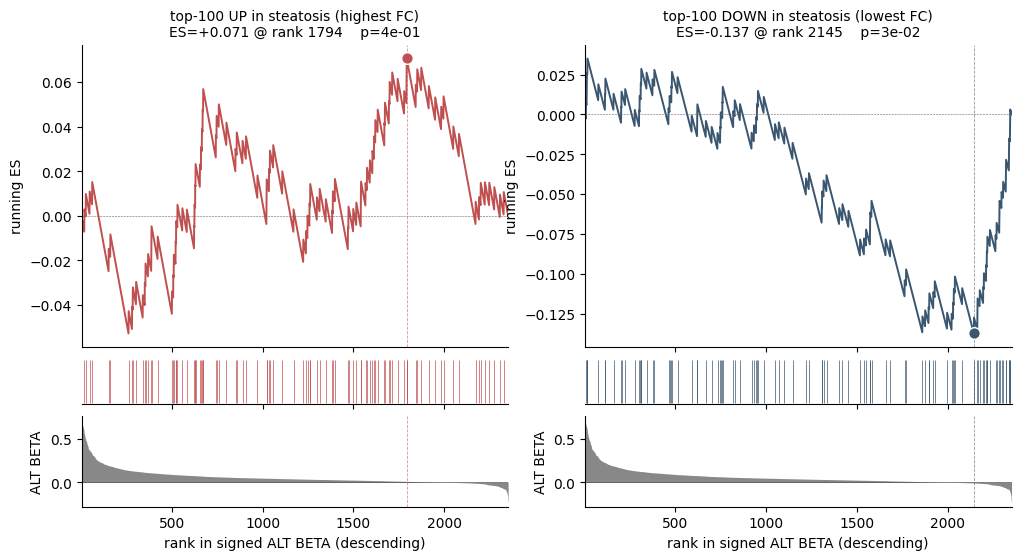

UP-set:   ES=+0.071  peak=1794  p=4e-01
DOWN-set: ES=-0.137  peak=2145  p=3e-02


In [14]:
order_st = np.argsort(-fc_st['ALT_BETA'].values)
beta_sorted_ids_st   = fc_st['gene_id'].values[order_st]
beta_sorted_betas_st = fc_st['ALT_BETA'].values[order_st]
top_up_st   = set(fc_st.nlargest(100,  'fc')['gene_id'])
top_down_st = set(fc_st.nsmallest(100, 'fc')['gene_id'])

r_up_st   = gsea_signed(top_up_st,   beta_sorted_ids_st)
r_down_st = gsea_signed(top_down_st, beta_sorted_ids_st)

fig = plt.figure(figsize=(12, 6))
outer = fig.add_gridspec(1, 2, wspace=0.18)
for col, (r, lbl, c) in enumerate([(r_up_st,   'top-100 UP in steatosis (highest FC)',   '#C04F4F'),
                                    (r_down_st, 'top-100 DOWN in steatosis (lowest FC)', '#3A5670')]):
    inner = outer[col].subgridspec(3, 1, height_ratios=[4, 0.6, 1.2], hspace=0.08)
    ax1, ax2, ax3 = (fig.add_subplot(inner[i]) for i in range(3))
    x = np.arange(1, len(r['rs']) + 1)
    ax1.plot(x, r['rs'], color=c, lw=1.4)
    ax1.axhline(0, color='#666', lw=0.4, ls='--')
    ax1.scatter(r['peak'] + 1, r['es'], color=c, s=70, edgecolor='white', zorder=3)
    ax1.axvline(r['peak'] + 1, color=c, ls='--', lw=0.6, alpha=0.6)
    ax1.set_xlim(1, len(x))
    ax1.set_title(f"{lbl}\nES={r['es']:+.3f} @ rank {r['peak']+1}    p={r['p']:.0e}", fontsize=10)
    ax1.set_ylabel('running ES'); ax1.tick_params(labelbottom=False)
    ax1.spines[['top', 'right']].set_visible(False)
    ax2.eventplot([np.where(r['hit'])[0] + 1], colors=[c], lineoffsets=[0.5], linelengths=[0.95], linewidths=0.5)
    ax2.axvline(r['peak'] + 1, color=c, ls='--', lw=0.6, alpha=0.6)
    ax2.set_xlim(1, len(x)); ax2.set_ylim(0, 1)
    ax2.set_yticks([]); ax2.tick_params(labelbottom=False, left=False)
    ax2.spines[['top', 'right', 'left']].set_visible(False)
    ax3.fill_between(x, 0, beta_sorted_betas_st, color='#888', lw=0)
    ax3.axhline(0, color='#333', lw=0.4)
    ax3.axvline(r['peak'] + 1, color=c, ls='--', lw=0.6, alpha=0.6)
    ax3.set_xlim(1, len(x))
    ax3.set_xlabel('rank in signed ALT BETA (descending)')
    ax3.set_ylabel('ALT BETA'); ax3.spines[['top', 'right']].set_visible(False)
fig.savefig(Config.FIGURES_DIR / 'ukbpp_liver_steatosis_fc_concordance.pdf', bbox_inches='tight')
plt.show()
print(f"UP-set:   ES={r_up_st['es']:+.3f}  peak={r_up_st['peak']+1}  p={r_up_st['p']:.0e}")
print(f"DOWN-set: ES={r_down_st['es']:+.3f}  peak={r_down_st['peak']+1}  p={r_down_st['p']:.0e}")


## 14.12 — FC concordance with sign(BETA) × −log10(p) ranking (steatosis)


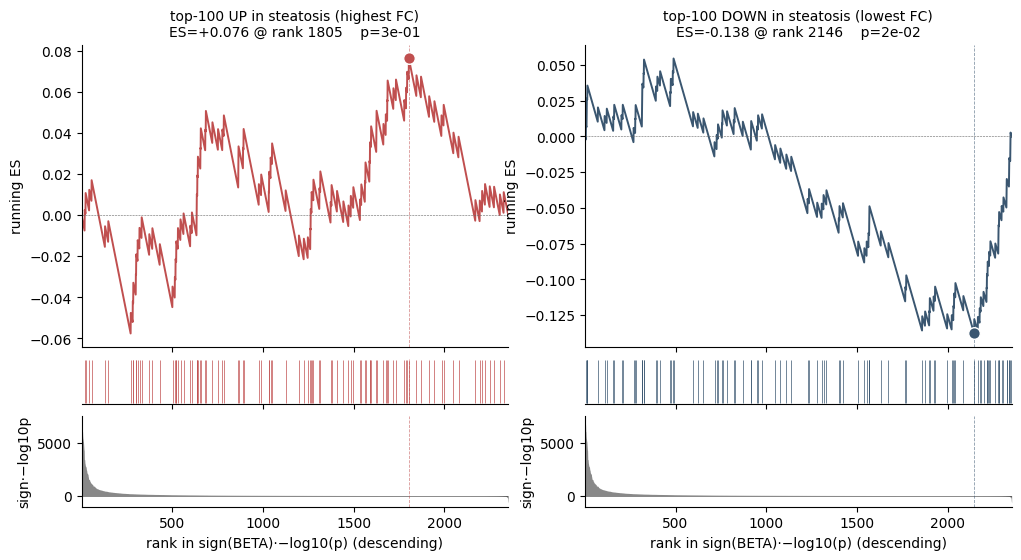

UP-set:   ES=+0.076  peak=1805  p=3e-01
DOWN-set: ES=-0.138  peak=2146  p=2e-02


In [15]:
metric_st = np.sign(uni_st[ALT_BETA].values) * uni_st[ALT_COL].values
order_st2 = np.argsort(-metric_st)
metric_sorted_ids_st  = fc_st['gene_id'].values[order_st2]
metric_sorted_vals_st = metric_st[order_st2]

r_up_st2   = gsea_signed(top_up_st,   metric_sorted_ids_st)
r_down_st2 = gsea_signed(top_down_st, metric_sorted_ids_st)

fig = plt.figure(figsize=(12, 6))
outer = fig.add_gridspec(1, 2, wspace=0.18)
for col, (r, lbl, c) in enumerate([(r_up_st2,   'top-100 UP in steatosis (highest FC)',   '#C04F4F'),
                                    (r_down_st2, 'top-100 DOWN in steatosis (lowest FC)', '#3A5670')]):
    inner = outer[col].subgridspec(3, 1, height_ratios=[4, 0.6, 1.2], hspace=0.08)
    ax1, ax2, ax3 = (fig.add_subplot(inner[i]) for i in range(3))
    x = np.arange(1, len(r['rs']) + 1)
    ax1.plot(x, r['rs'], color=c, lw=1.4)
    ax1.axhline(0, color='#666', lw=0.4, ls='--')
    ax1.scatter(r['peak'] + 1, r['es'], color=c, s=70, edgecolor='white', zorder=3)
    ax1.axvline(r['peak'] + 1, color=c, ls='--', lw=0.6, alpha=0.6)
    ax1.set_xlim(1, len(x))
    ax1.set_title(f"{lbl}\nES={r['es']:+.3f} @ rank {r['peak']+1}    p={r['p']:.0e}", fontsize=10)
    ax1.set_ylabel('running ES'); ax1.tick_params(labelbottom=False)
    ax1.spines[['top', 'right']].set_visible(False)
    ax2.eventplot([np.where(r['hit'])[0] + 1], colors=[c], lineoffsets=[0.5], linelengths=[0.95], linewidths=0.5)
    ax2.axvline(r['peak'] + 1, color=c, ls='--', lw=0.6, alpha=0.6)
    ax2.set_xlim(1, len(x)); ax2.set_ylim(0, 1)
    ax2.set_yticks([]); ax2.tick_params(labelbottom=False, left=False)
    ax2.spines[['top', 'right', 'left']].set_visible(False)
    ax3.fill_between(x, 0, metric_sorted_vals_st, color='#888', lw=0)
    ax3.axhline(0, color='#333', lw=0.4)
    ax3.axvline(r['peak'] + 1, color=c, ls='--', lw=0.6, alpha=0.6)
    ax3.set_xlim(1, len(x))
    ax3.set_xlabel('rank in sign(BETA)·−log10(p) (descending)')
    ax3.set_ylabel('sign·−log10p'); ax3.spines[['top', 'right']].set_visible(False)
fig.savefig(Config.FIGURES_DIR / 'ukbpp_liver_steatosis_fc_concordance_signlog10p.pdf', bbox_inches='tight')
plt.show()
print(f"UP-set:   ES={r_up_st2['es']:+.3f}  peak={r_up_st2['peak']+1}  p={r_up_st2['p']:.0e}")
print(f"DOWN-set: ES={r_down_st2['es']:+.3f}  peak={r_down_st2['peak']+1}  p={r_down_st2['p']:.0e}")


# Blood expression → Plasma-protein MR validation

Use blood RNA-seq FC to prioritise candidates, then Mendelian Randomization tests whether their plasma protein levels are causal for liver disease (FinnGen R12).

In [16]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from trace_path.config import Config
Config.ensure_dirs()
import re

TPM_FILE   = Config.RAW_DIR / 'GTEx_Analysis_v10_RNASeQCv2.4.2_gene_tpm.gct'
SA_FILE    = Config.RAW_DIR / 'GTEx_Analysis_v10_Annotations_SampleAttributesDS.txt'
PATH_FILE  = Config.PROCESSED_DIR / 'liver_pathology_labels_imputed.csv'
ST7_FILE   = Config.RAW_DIR / '41586_2023_6592_MOESM3_ESM.xlsx'
CACHE_FILE = Config.CACHE_DIR / 'blood_tpm.parquet'
FG_DIR     = Config.RAW_DIR / 'finngen_r12'

## 14.13 — Extract whole-blood TPM from GTEx

~755 whole-blood RNA-seq samples in GTEx v10 (SMTSD == 'Whole Blood'). Cached as parquet.

In [17]:
if CACHE_FILE.exists():
    blood_tpm = pd.read_parquet(CACHE_FILE)
    print(f'Loaded cached blood TPM: {blood_tpm.shape}')
else:
    sa = pd.read_csv(SA_FILE, sep='\t', low_memory=False)
    blood_samps = sa[(sa['SMTSD'] == 'Whole Blood') & (sa['SMAFRZE'] == 'RNASEQ')]['SAMPID'].tolist()
    print(f'Whole-blood RNA-seq samples: {len(blood_samps)}')

    with open(TPM_FILE) as f:
        f.readline(); f.readline()
        header = f.readline().strip().split('\t')

    usecols = ['Name', 'Description'] + [s for s in blood_samps if s in header]
    print(f'Columns to extract: {len(usecols) - 2} blood + 2 annotation')
    print('Reading 6.8 GB TPM file (this takes a few minutes)...')

    blood_tpm = pd.read_csv(TPM_FILE, sep='\t', skiprows=2, usecols=usecols)
    blood_tpm = blood_tpm.rename(columns={'Name': 'gene_id', 'Description': 'gene_name'})
    blood_tpm.to_parquet(CACHE_FILE, index=False)
    print(f'Saved cache: {blood_tpm.shape}')

print(f'Genes: {blood_tpm.shape[0]:,}  |  Samples: {blood_tpm.shape[1] - 2}')

Loaded cached blood TPM: (59033, 805)
Genes: 59,033  |  Samples: 803


## 14.14 — Match blood samples to donor's liver pathology

Each donor has one liver pathology label. Maps blood sample IDs → donor (GTEX-XXXX) → donor's liver pathology.

In [18]:
# Fix I1 + I2: use the NLP-aware, tissue-filtered labeler instead of the
# structured-only substring match. `assign_donor_labels` filters `df_meta_url`
# to Liver samples before groupby, so the drop_duplicates('donor_id') mistake
# from the old code (which could pick a non-Liver row's Pathology.Categories)
# is avoided by construction.
from trace_path.data import load_cache
from trace_path.labels import assign_donor_labels

_, blood_subjid, _, df_meta_url, _ = load_cache()

samp_cols = [c for c in blood_tpm.columns if c.startswith('GTEX-')]

# blood_subjid is a Series with SAMPID -> SUBJID mapping. Restrict to samples
# actually present in blood_tpm so we don't map to unknown SAMPIDs downstream.
sid = blood_subjid[blood_subjid.index.isin(samp_cols)]

y_cirr,  _, n_cp, n_cn = assign_donor_labels(df_meta_url, 'Liver', 'cirrhosis',  sid)
y_steat, _, n_sp, n_sn = assign_donor_labels(df_meta_url, 'Liver', 'steatosis', sid)

# y_* is a Series indexed by SAMPID with 0/1/NaN. NaN = no Liver annotation
# for that donor. Assemble a labels frame compatible with compute_blood_fc().
labels = pd.DataFrame({
    'sampid':         sid.index,
    'donor_id':       sid.values,
    'has_cirrhosis':  y_cirr.values,
    'has_steatosis':  y_steat.values,
})
# Drop donors with no Liver label at all; keep those with only cirrhosis or only
# steatosis annotated (has_* becomes 0 for the un-annotated column since the
# donor was seen in a Liver sample).
labels = labels.dropna(subset=['has_cirrhosis', 'has_steatosis'], how='all')
labels['has_cirrhosis'] = labels['has_cirrhosis'].fillna(0).astype(int)
labels['has_steatosis'] = labels['has_steatosis'].fillna(0).astype(int)

print(f'Matched: {len(labels)} / {len(samp_cols)} blood samples to Liver-pathology labels')
print(f'  Cirrhosis: {labels.has_cirrhosis.sum():>3} positive  vs {(labels.has_cirrhosis == 0).sum():>3} negative')
print(f'  Steatosis: {labels.has_steatosis.sum():>3} positive  vs {(labels.has_steatosis == 0).sum():>3} negative')


Loaded cache from /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/TRACE/data/cache/processed_data.pkl
  X_wb: 803 samples × 59033 genes
Matched: 435 / 803 blood samples to Liver-pathology labels
  Cirrhosis:  49 positive  vs 386 negative
  Steatosis: 216 positive  vs 219 negative


## 14.15 — Compute blood FC for steatosis & cirrhosis

FC = mean(blood TPM | donor's liver has pathology) / mean(blood TPM | doesn't), +1 pseudocount.

In [19]:
def compute_blood_fc(blood_tpm, labels, condition_col):
    pos = labels.loc[labels[condition_col] == 1, 'sampid'].tolist()
    neg = labels.loc[labels[condition_col] == 0, 'sampid'].tolist()
    tpm = blood_tpm[pos + neg].values.astype(np.float32)
    n_pos = len(pos)
    mean_pos = tpm[:, :n_pos].mean(axis=1) + 1
    mean_neg = tpm[:, n_pos:].mean(axis=1) + 1
    fc = mean_pos / mean_neg
    return pd.DataFrame({'gene_id': blood_tpm['gene_id'].values,
                         'gene_name': blood_tpm['gene_name'].values,
                         'fc': fc, 'log2fc': np.log2(fc)})

fc_cirr  = compute_blood_fc(blood_tpm, labels, 'has_cirrhosis')
fc_steat = compute_blood_fc(blood_tpm, labels, 'has_steatosis')

print('Top-5 UP in steatosis (blood):')
print(fc_steat.nlargest(5, 'fc')[['gene_name','fc','log2fc']].to_string(index=False))
print('\nTop-5 UP in cirrhosis (blood):')
print(fc_cirr.nlargest(5, 'fc')[['gene_name','fc','log2fc']].to_string(index=False))

Top-5 UP in steatosis (blood):
gene_name       fc   log2fc
    DEFB1 3.542079 1.824596
     CD1A 3.237383 1.694828
     CD1E 2.984329 1.577407
     HAMP 2.769371 1.469558
     CD1B 2.660628 1.411767

Top-5 UP in cirrhosis (blood):
      gene_name        fc   log2fc
ENSG00000280800 10.203938 3.351054
       IGLV4-60  3.520795 1.815901
          IFI27  2.978707 1.574686
   IGKV3OR2-268  2.607028 1.382406
        CD177P1  2.259300 1.175876


## 14.16 — Intersect with Olink + save top-100 UP files

Restrict to genes measurable in UKB-PPP Olink plasma panel (Sun et al. ST7). Save top-100 UP by blood FC.

In [20]:
st7 = pd.read_excel(ST7_FILE, sheet_name='ST7', header=None)
top, sub = st7.iloc[3].ffill(), st7.iloc[4]
_PREFIX = re.compile(r'^[A-Z][0-9]{1,3}[A-Z0-9]?_')

def _flatten(t, s):
    t = '' if pd.isna(t) else str(t).strip()
    s = '' if pd.isna(s) else str(s).strip()
    if not s: return t
    if not t: return s
    return f'{t}|{_PREFIX.sub("", s)}'

st7_data = st7.iloc[5:].copy()
st7_data.columns = [_flatten(t, s) for t, s in zip(top, sub)]
st7_data = st7_data.reset_index(drop=True)
st7_data['gene_symbol'] = st7_data['UKBPPP ProteinID'].astype(str).str.split(':').str[0]

ALT_BETA = 'ALT (liver function)|BETA'
ALT_LOG  = 'ALT (liver function)|log10(p)'
for c in (ALT_BETA, ALT_LOG):
    st7_data[c] = pd.to_numeric(st7_data[c], errors='coerce')

st7_lookup = (st7_data[['gene_symbol', ALT_BETA, ALT_LOG]]
              .sort_values(ALT_LOG, ascending=False)
              .drop_duplicates('gene_symbol'))
olink_genes = set(st7_lookup['gene_symbol'])
print(f'Olink panel: {len(olink_genes)} unique gene symbols\n')

for fc_df, name in [(fc_steat, 'steatosis'), (fc_cirr, 'cirrhosis')]:
    uni = fc_df[fc_df['gene_name'].isin(olink_genes)].copy()
    uni = uni.merge(st7_lookup, left_on='gene_name', right_on='gene_symbol', how='left')
    uni.nlargest(100, 'fc').to_csv(Config.TABLES_DIR / f'blood_fc_{name}_top100_up.csv', index=False)
    uni.nsmallest(100, 'fc').to_csv(Config.TABLES_DIR / f'blood_fc_{name}_top100_down.csv', index=False)
    print(f'{name}: {len(uni)} genes in Olink universe → top-100 UP + top-100 DOWN saved')

Olink panel: 2923 unique gene symbols

steatosis: 2898 genes in Olink universe → top-100 UP + top-100 DOWN saved
cirrhosis: 2898 genes in Olink universe → top-100 UP + top-100 DOWN saved


## 14.17 — Sun ST9 cis-pQTL instruments + MR helpers

Same logic as NB15 §15.9.1 (also in NB15). Loads `st9_sig` and defines `gene_inst`, `bulk_pull`, `mr_sweep_same_dir`.

In [21]:
P_THRESH = 0.05
LOG_THRESH = -np.log10(P_THRESH)
st9 = pd.read_excel(ST7_FILE, sheet_name='ST9', header=4)
st9['gene_symbol'] = st9['UKBPPP ProteinID'].astype(str).str.split(':').str[0]
st9_sig = st9[(st9['cis/trans'] == 'cis') & (st9['log10(p) (discovery)'] > LOG_THRESH)]
print(f'ST9 cis filter: p < {P_THRESH} → {len(st9_sig):,} cis-pQTLs retained')

PHENOS = [('NAFLD', 3504), ('NASH', 254), ('CIRRHOSIS_BROAD', 5545),
          ('K11_FIBROCHIRLIV', 2653), ('CHIRHEP_NAS', 1703), ('FIBROLIV', 214)]

def gene_inst(g):
    h = st9_sig[st9_sig.gene_symbol == g]
    if not len(h): return None
    r = h.iloc[0]
    A0, A1 = r['Variant ID (CHROM:GENPOS (hg37):A0:A1:imp:v1)'].split(':')[2:4]
    return dict(gene=g, rsid=r['rsID'], beta_exp=float(r['BETA (discovery, wrt. A1)']),
                A0=A0, A1=A1)

def bulk_pull(gz, rsids):
    target = set(rsids); out = []
    for chunk in pd.read_csv(gz, sep='\t', compression='gzip', chunksize=500_000):
        h = chunk[chunk['rsids'].isin(target)]
        if len(h): out.append(h)
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()

def mr_sweep_same_dir(top_file, label):
    top = pd.read_csv(top_file)
    inst = pd.DataFrame([i for g in top.gene_name if (i := gene_inst(g)) is not None])
    fg = {}
    for ph, _ in PHENOS:
        cache = Config.CACHE_DIR / f'fg_{label}_{ph}.parquet'
        if cache.exists():
            fg[ph] = pd.read_parquet(cache).drop_duplicates('rsids').set_index('rsids')
        else:
            df = bulk_pull(FG_DIR / f'finngen_R12_{ph}.gz', inst.rsid)
            df.to_parquet(cache, index=False)
            fg[ph] = df.drop_duplicates('rsids').set_index('rsids')

    rows = []
    for _, x in inst.iterrows():
        for ph, _ in PHENOS:
            if x.rsid not in fg[ph].index: continue
            v = fg[ph].loc[x.rsid]
            b_out = (-1 if v['alt'] != x.A1 else 1) * float(v['beta'])
            se_out = float(v['sebeta'])
            bMR, sMR = b_out / x.beta_exp, se_out / abs(x.beta_exp)
            rows.append(dict(Gene=x.gene, Phenotype=ph,
                             beta_exp=x.beta_exp, beta_out=b_out, SE=se_out,
                             p_out=float(v['pval']),
                             wald_beta=bMR, SE_MR=sMR,
                             p_MR=2*(1-norm.cdf(abs(bMR/sMR))),
                             same_dir=np.sign(b_out) == np.sign(x.beta_exp)))
    all_mr = pd.DataFrame(rows)
    mr = all_mr[all_mr.same_dir].drop(columns='same_dir').sort_values('p_MR').reset_index(drop=True)
    mr.to_csv(Config.TABLES_DIR / f'mr_{label}_up100_same_direction.csv', index=False)

    n_start = len(top)
    n_cis   = len(inst)
    n_in_fg = inst.gene[inst.rsid.isin(set().union(*[set(fg[ph].index) for ph, _ in PHENOS]))].nunique()
    n_sig_any = all_mr[all_mr.p_out < 0.05].Gene.nunique()
    n_sd_sig  = mr[mr.p_MR < 0.05].Gene.nunique()
    print(f'=== {label.upper()} — gene-level funnel ===')
    print(f'  {n_start:>3}  starting genes (top-100 UP by blood FC)')
    print(f'  {n_cis:>3}  with a cis-pQTL instrument in Sun ST9        ({n_start-n_cis} dropped: no plasma cis-pQTL)')
    print(f'  {n_in_fg:>3}  rsID found in FinnGen R12                    ({n_cis-n_in_fg} dropped: rsID absent in FinnGen)')
    print(f'  {n_sig_any:>3}  with ≥1 FinnGen p<0.05 hit across 6 phenotypes (any direction)')
    print(f'  {n_sd_sig:>3}  ALSO same-direction as plasma  ← causal candidates')
    print(f'\nCandidate genes ({n_sd_sig}): ' + ', '.join(sorted(mr.loc[mr.p_MR<0.05, 'Gene'].unique())))

    print(f'\nSame-direction MR tests by phenotype:')
    print(f"  {'Phenotype':<18} {'n_tests':>8} {'p<0.05':>8}")
    for ph, _ in PHENOS:
        sub = mr[mr.Phenotype == ph]
        print(f'  {ph:<18} {len(sub):>8} {(sub.p_MR<0.05).sum():>8}')
    print(f"  {'TOTAL':<18} {len(mr):>8} {(mr.p_MR<0.05).sum():>8}")

    print(f'\nFull same-direction MR table ({len(mr)} rows, sorted by p_MR):')
    fmt = mr.copy()
    for c in ('beta_exp','beta_out'):  fmt[c] = fmt[c].map(lambda x: f'{x:+.4f}')
    for c in ('SE','SE_MR'):           fmt[c] = fmt[c].map(lambda x: f'{x:.4f}')
    fmt['wald_beta'] = fmt['wald_beta'].map(lambda x: f'{x:+.3f}')
    for c in ('p_out','p_MR'):         fmt[c] = fmt[c].map(lambda x: f'{x:.4f}')
    fmt = fmt.rename(columns={'beta_exp':'β_exp', 'beta_out':'β_out', 'wald_beta':'Wald β'})
    print(fmt.to_string(index=False))
    return mr

ST9 cis filter: p < 0.05 → 1,955 cis-pQTLs retained


## 14.18 — Same-direction MR sweep: blood-UP steatosis top-100 → 6 FinnGen liver outcomes

In [22]:
mr_blood_steat = mr_sweep_same_dir(Config.TABLES_DIR / 'blood_fc_steatosis_top100_up.csv', 'blood_steatosis')

=== BLOOD_STEATOSIS — gene-level funnel ===
  100  starting genes (top-100 UP by blood FC)
   66  with a cis-pQTL instrument in Sun ST9        (34 dropped: no plasma cis-pQTL)
   63  rsID found in FinnGen R12                    (3 dropped: rsID absent in FinnGen)
   13  with ≥1 FinnGen p<0.05 hit across 6 phenotypes (any direction)
    7  ALSO same-direction as plasma  ← causal candidates

Candidate genes (7): AIF1, CPPED1, GIMAP7, GLRX, MINDY1, SERPINH1, TCL1A

Same-direction MR tests by phenotype:
  Phenotype           n_tests   p<0.05
  NAFLD                    33        2
  NASH                     34        1
  CIRRHOSIS_BROAD          34        1
  K11_FIBROCHIRLIV         37        0
  CHIRHEP_NAS              30        1
  FIBROLIV                 32        2
  TOTAL                   200        7

Full same-direction MR table (200 rows, sorted by p_MR):
     Gene        Phenotype   β_exp   β_out     SE  p_out Wald β  SE_MR   p_MR
   MINDY1            NAFLD -0.6279 -0.2872 0.09

## 14.19 — Same-direction MR sweep: blood-UP cirrhosis top-100 → 6 FinnGen liver outcomes

In [23]:
mr_blood_cirr = mr_sweep_same_dir(Config.TABLES_DIR / 'blood_fc_cirrhosis_top100_up.csv', 'blood_cirrhosis')

=== BLOOD_CIRRHOSIS — gene-level funnel ===
  100  starting genes (top-100 UP by blood FC)
   82  with a cis-pQTL instrument in Sun ST9        (18 dropped: no plasma cis-pQTL)
   73  rsID found in FinnGen R12                    (9 dropped: rsID absent in FinnGen)
   28  with ≥1 FinnGen p<0.05 hit across 6 phenotypes (any direction)
   15  ALSO same-direction as plasma  ← causal candidates

Candidate genes (15): ACHE, ASGR2, C7, CCL24, CD177, CEACAM6, CREG1, DNAJC6, FKBP1B, SERPINE1, SLC4A1, TFF1, THBS2, TIMP4, TNC

Same-direction MR tests by phenotype:
  Phenotype           n_tests   p<0.05
  NAFLD                    38        4
  NASH                     43        3
  CIRRHOSIS_BROAD          33        3
  K11_FIBROCHIRLIV         42        3
  CHIRHEP_NAS              37        2
  FIBROLIV                 38        4
  TOTAL                   231       19

Full same-direction MR table (231 rows, sorted by p_MR):
    Gene        Phenotype   β_exp   β_out     SE  p_out Wald β  SE_MR  

## 14.20 — Opposite-direction MR: blood-DOWN steatosis top-100 → 6 FinnGen liver outcomes

Mirror of §14.18: top-100 DOWN-in-blood genes, keeping rows where cis-pQTL and FinnGen effects have opposite signs (protective-protein logic).

In [24]:
def mr_sweep_opposite_dir(top_file, label):
    """Wald MR sweep keeping rows where sign(β_out) != sign(β_exp); mirrors mr_sweep_same_dir with inverted filter and its own FinnGen cache."""
    top = pd.read_csv(top_file)
    inst = pd.DataFrame([i for g in top.gene_name if (i := gene_inst(g)) is not None])
    fg = {}
    for ph, _ in PHENOS:
        cache = Config.CACHE_DIR / f'fg_{label}_{ph}.parquet'
        if cache.exists():
            fg[ph] = pd.read_parquet(cache).drop_duplicates('rsids').set_index('rsids')
        else:
            df = bulk_pull(FG_DIR / f'finngen_R12_{ph}.gz', inst.rsid)
            df.to_parquet(cache, index=False)
            fg[ph] = df.drop_duplicates('rsids').set_index('rsids')

    rows = []
    for _, x in inst.iterrows():
        for ph, _ in PHENOS:
            if x.rsid not in fg[ph].index: continue
            v = fg[ph].loc[x.rsid]
            b_out = (-1 if v['alt'] != x.A1 else 1) * float(v['beta'])
            se_out = float(v['sebeta'])
            bMR, sMR = b_out / x.beta_exp, se_out / abs(x.beta_exp)
            rows.append(dict(Gene=x.gene, Phenotype=ph,
                             beta_exp=x.beta_exp, beta_out=b_out, SE=se_out,
                             p_out=float(v['pval']),
                             wald_beta=bMR, SE_MR=sMR,
                             p_MR=2*(1-norm.cdf(abs(bMR/sMR))),
                             opp_dir=np.sign(b_out) == -np.sign(x.beta_exp)))
    all_mr = pd.DataFrame(rows)
    mr = all_mr[all_mr.opp_dir].drop(columns='opp_dir').sort_values('p_MR').reset_index(drop=True)
    mr.to_csv(Config.TABLES_DIR / f'mr_{label}_opposite_direction.csv', index=False)

    n_start = len(top)
    n_cis   = len(inst)
    n_in_fg = inst.gene[inst.rsid.isin(set().union(*[set(fg[ph].index) for ph, _ in PHENOS]))].nunique()
    n_sig_any = all_mr[all_mr.p_out < 0.05].Gene.nunique()
    n_opp_sig = mr[mr.p_MR < 0.05].Gene.nunique()
    print(f'=== {label.upper()} OPPOSITE-direction — gene-level funnel ===')
    print(f'  {n_start:>3}  starting genes (top-100 DOWN by FC)')
    print(f'  {n_cis:>3}  with a cis-pQTL instrument in Sun ST9        ({n_start-n_cis} dropped: no plasma cis-pQTL)')
    print(f'  {n_in_fg:>3}  rsID found in FinnGen R12                    ({n_cis-n_in_fg} dropped: rsID absent in FinnGen)')
    print(f'  {n_sig_any:>3}  with ≥1 FinnGen p<0.05 hit across 6 phenotypes (any direction)')
    print(f'  {n_opp_sig:>3}  ALSO opposite-direction (β_exp vs β_out)  ← causal protective candidates')
    print(f'\nProtective candidate genes ({n_opp_sig}): ' + ', '.join(sorted(mr.loc[mr.p_MR<0.05, 'Gene'].unique())))

    print(f'\nOpposite-direction MR tests by phenotype:')
    print(f"  {'Phenotype':<18} {'n_tests':>8} {'p<0.05':>8}")
    for ph, _ in PHENOS:
        sub = mr[mr.Phenotype == ph]
        print(f'  {ph:<18} {len(sub):>8} {(sub.p_MR<0.05).sum():>8}')
    print(f"  {'TOTAL':<18} {len(mr):>8} {(mr.p_MR<0.05).sum():>8}")

    print(f'\nFull opposite-direction MR table ({len(mr)} rows, sorted by p_MR):')
    fmt = mr.copy()
    for c in ('beta_exp','beta_out'):  fmt[c] = fmt[c].map(lambda x: f'{x:+.4f}')
    for c in ('SE','SE_MR'):           fmt[c] = fmt[c].map(lambda x: f'{x:.4f}')
    fmt['wald_beta'] = fmt['wald_beta'].map(lambda x: f'{x:+.3f}')
    for c in ('p_out','p_MR'):         fmt[c] = fmt[c].map(lambda x: f'{x:.4f}')
    fmt = fmt.rename(columns={'beta_exp':'β_exp', 'beta_out':'β_out', 'wald_beta':'Wald β'})
    print(fmt.to_string(index=False))
    return mr

mr_opp_blood_steat = mr_sweep_opposite_dir(Config.TABLES_DIR / 'blood_fc_steatosis_top100_down.csv', 'blood_steat_down')

=== BLOOD_STEAT_DOWN OPPOSITE-direction — gene-level funnel ===
  100  starting genes (top-100 DOWN by FC)
   88  with a cis-pQTL instrument in Sun ST9        (12 dropped: no plasma cis-pQTL)
   79  rsID found in FinnGen R12                    (9 dropped: rsID absent in FinnGen)
   26  with ≥1 FinnGen p<0.05 hit across 6 phenotypes (any direction)
   12  ALSO opposite-direction (β_exp vs β_out)  ← causal protective candidates

Protective candidate genes (12): ADH1B, APOM, C3, CFB, FABP4, GMPR, IGLC2, LGMN, SERPINA11, SERPINC1, TREM2, TRIM58

Opposite-direction MR tests by phenotype:
  Phenotype           n_tests   p<0.05
  NAFLD                    33        2
  NASH                     38        3
  CIRRHOSIS_BROAD          38        4
  K11_FIBROCHIRLIV         41        5
  CHIRHEP_NAS              36        3
  FIBROLIV                 31        2
  TOTAL                   217       19

Full opposite-direction MR table (217 rows, sorted by p_MR):
     Gene        Phenotype   β_exp  

## 14.21 — Opposite-direction MR: blood-DOWN cirrhosis top-100 → 6 FinnGen liver outcomes

In [25]:
mr_opp_blood_cirr = mr_sweep_opposite_dir(Config.TABLES_DIR / 'blood_fc_cirrhosis_top100_down.csv', 'blood_cirr_down')

=== BLOOD_CIRR_DOWN OPPOSITE-direction — gene-level funnel ===
  100  starting genes (top-100 DOWN by FC)
   78  with a cis-pQTL instrument in Sun ST9        (22 dropped: no plasma cis-pQTL)
   67  rsID found in FinnGen R12                    (11 dropped: rsID absent in FinnGen)
   17  with ≥1 FinnGen p<0.05 hit across 6 phenotypes (any direction)
    8  ALSO opposite-direction (β_exp vs β_out)  ← causal protective candidates

Protective candidate genes (8): CFB, CXCL8, FABP1, FCER2, GBP4, GZMH, SERPINC1, SULT2A1

Opposite-direction MR tests by phenotype:
  Phenotype           n_tests   p<0.05
  NAFLD                    29        1
  NASH                     29        3
  CIRRHOSIS_BROAD          37        1
  K11_FIBROCHIRLIV         32        2
  CHIRHEP_NAS              32        1
  FIBROLIV                 33        3
  TOTAL                   192       11

Full opposite-direction MR table (192 rows, sorted by p_MR):
    Gene        Phenotype   β_exp   β_out     SE  p_out Wald β  

## 14.22 — Manuscript forest plot: Blood-steatosis MR proof-of-concept

Two-panel forest of blood-steatosis prioritised genes: causal drivers (same-direction MR) and causal protective (opposite-direction MR), per-row β_exp and β_out dual axes.

/var/folders/bv/6z9_9t8j4m10s0k827gq9bhr0000gn/T/ipykernel_74303/152919381.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


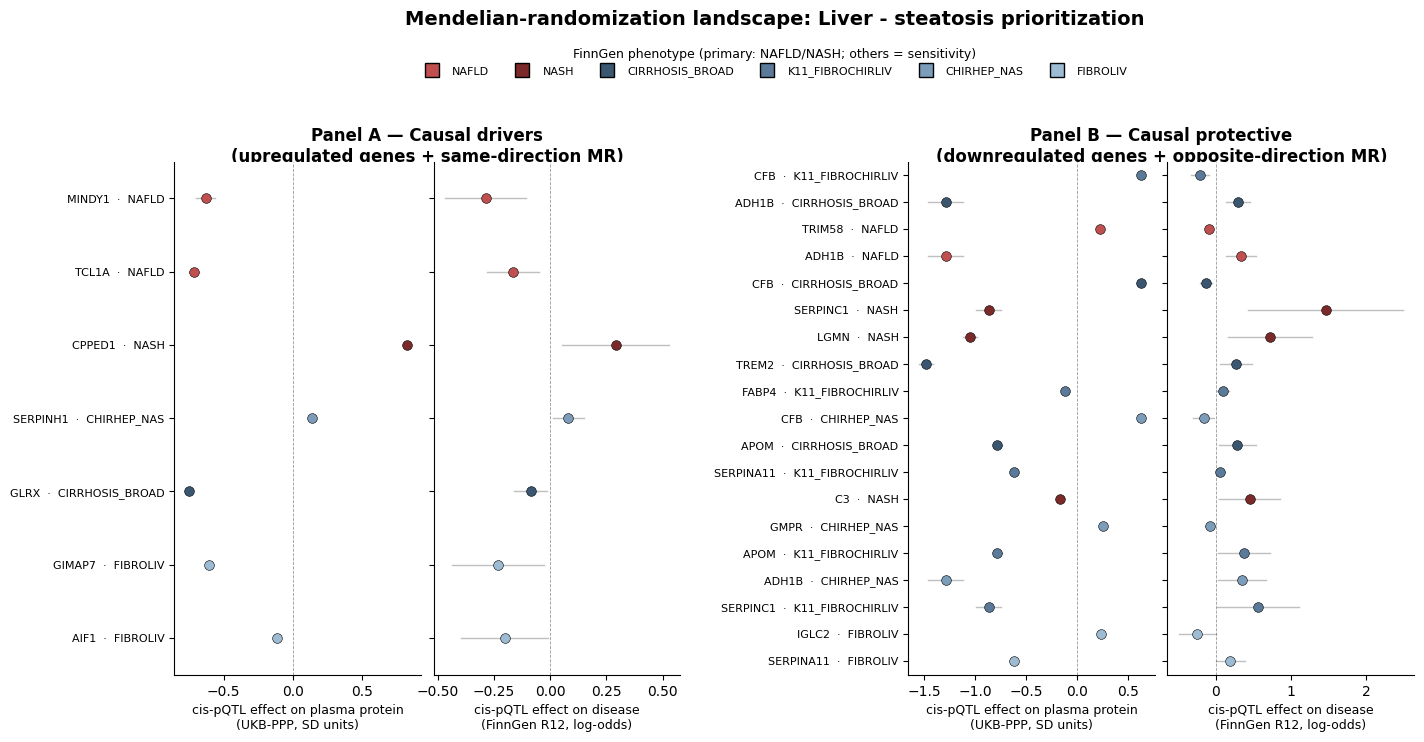

Saved: /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/TRACE/output/figures/figure_4.pdf
Panel A (drivers):    7 hits, 7 unique genes
Panel B (protective): 19 hits, 12 unique genes


In [26]:
import matplotlib.pyplot as plt
T = Config.TABLES_DIR

DRIVER_FILES  = ['mr_blood_steatosis_up100_same_direction.csv']   # liver-steatosis-UP only
PROTECT_FILES = ['mr_blood_steat_down_opposite_direction.csv']  # liver-steatosis-DOWN only

_st9 = pd.read_excel(ST7_FILE, sheet_name='ST9', header=4)
_st9['gene_symbol'] = _st9['UKBPPP ProteinID'].astype(str).str.split(':').str[0]
SE_EXP_LOOKUP = (_st9[_st9['cis/trans'] == 'cis']
                 .drop_duplicates('gene_symbol')
                 .set_index('gene_symbol')['SE (discovery)'].to_dict())

def load_sig(files):
    rows = [pd.read_csv(T / n) for n in files]
    sig = pd.concat(rows, ignore_index=True)
    sig = sig[sig['p_MR'] < 0.05].copy()
    sig['SE_exp'] = sig['Gene'].map(SE_EXP_LOOKUP)
    return sig.sort_values('p_MR').reset_index(drop=True)

driver  = load_sig(DRIVER_FILES)
protect = load_sig(PROTECT_FILES)

phen_palette = {
    'NAFLD':            '#C04F4F',
    'NASH':             '#7C2929',
    'CIRRHOSIS_BROAD':  '#3A5670',
    'K11_FIBROCHIRLIV': '#5B7A99',
    'CHIRHEP_NAS':      '#7B9DBA',
    'FIBROLIV':         '#9DBCD3',
}

n_max = max(len(driver), len(protect), 1)
fig = plt.figure(figsize=(16, max(7, n_max * 0.32)))
outer = fig.add_gridspec(1, 2, wspace=0.45)

PANELS = [
    (driver,  'Panel A — Causal drivers\n(upregulated genes + same-direction MR)'),
    (protect, 'Panel B — Causal protective\n(downregulated genes + opposite-direction MR)'),
]

for panel_idx, (df, panel_title) in enumerate(PANELS):
    inner = outer[panel_idx].subgridspec(2, 2, height_ratios=[0.04, 1], hspace=0.02, wspace=0.05)
    title_ax = fig.add_subplot(inner[0, :]); title_ax.axis('off')
    title_ax.text(0.5, 0.5, panel_title, ha='center', va='center', fontsize=12, fontweight='bold')
    ax_exp = fig.add_subplot(inner[1, 0])
    ax_out = fig.add_subplot(inner[1, 1], sharey=ax_exp)

    df = df.iloc[::-1].reset_index(drop=True)
    y = np.arange(len(df))
    for i, row in df.iterrows():
        c = phen_palette.get(row['Phenotype'], 'gray')
        se_exp = row['SE_exp']
        if pd.notna(se_exp):
            ax_exp.plot([row['beta_exp']-1.96*se_exp, row['beta_exp']+1.96*se_exp],
                        [y[i], y[i]], color='gray', alpha=0.5, lw=1, zorder=1)
        ax_exp.plot(row['beta_exp'], y[i], 'o', color=c, markersize=7,
                    markeredgecolor='black', markeredgewidth=0.4, zorder=3)
        ax_out.plot([row['beta_out']-1.96*row['SE'], row['beta_out']+1.96*row['SE']],
                    [y[i], y[i]], color='gray', alpha=0.5, lw=1, zorder=1)
        ax_out.plot(row['beta_out'], y[i], 'o', color=c, markersize=7,
                    markeredgecolor='black', markeredgewidth=0.4, zorder=3)

    ax_exp.set_yticks(y)
    ax_exp.set_yticklabels([f'{r.Gene}  ·  {r.Phenotype}' for _, r in df.iterrows()], fontsize=8)
    ax_out.tick_params(axis='y', labelleft=False)
    for ax in (ax_exp, ax_out):
        ax.axvline(0, color='black', ls='--', lw=0.6, alpha=0.4)
        ax.spines[['top','right']].set_visible(False)
        ax.set_ylim(-0.5, len(df) - 0.5)
    ax_exp.set_xlabel('cis-pQTL effect on plasma protein\n(UKB-PPP, SD units)', fontsize=9)
    ax_out.set_xlabel('cis-pQTL effect on disease\n(FinnGen R12, log-odds)', fontsize=9)

phen_handles = [plt.Line2D([0],[0], marker='s', color='w', markerfacecolor=c, markersize=10,
                            markeredgecolor='black', label=p)
                for p, c in phen_palette.items()]
fig.legend(handles=phen_handles, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=6, frameon=False, title='FinnGen phenotype (primary: NAFLD/NASH; others = sensitivity)',
           fontsize=8, title_fontsize=9)
fig.suptitle('Mendelian-randomization landscape: Liver - steatosis prioritization', y=1.06, fontsize=14, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.95])
out_pdf = Config.FIGURES_DIR / 'figure_5.pdf'
fig.savefig(out_pdf, bbox_inches='tight')
fig.savefig(Config.FIGURES_DIR / 'figure_5.png', bbox_inches='tight', dpi=200)
plt.show()
print(f'Saved: {out_pdf}')
print(f'Panel A (drivers):    {len(driver)} hits, {driver.Gene.nunique()} unique genes')
print(f'Panel B (protective): {len(protect)} hits, {protect.Gene.nunique()} unique genes')

## 14.23 — Manuscript forest plot: Blood-cirrhosis MR

Same layout as §14.22 applied to the blood-cirrhosis prioritisation, using the sweep CSVs from §14.19 and §14.21.

/var/folders/bv/6z9_9t8j4m10s0k827gq9bhr0000gn/T/ipykernel_74303/2381642204.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


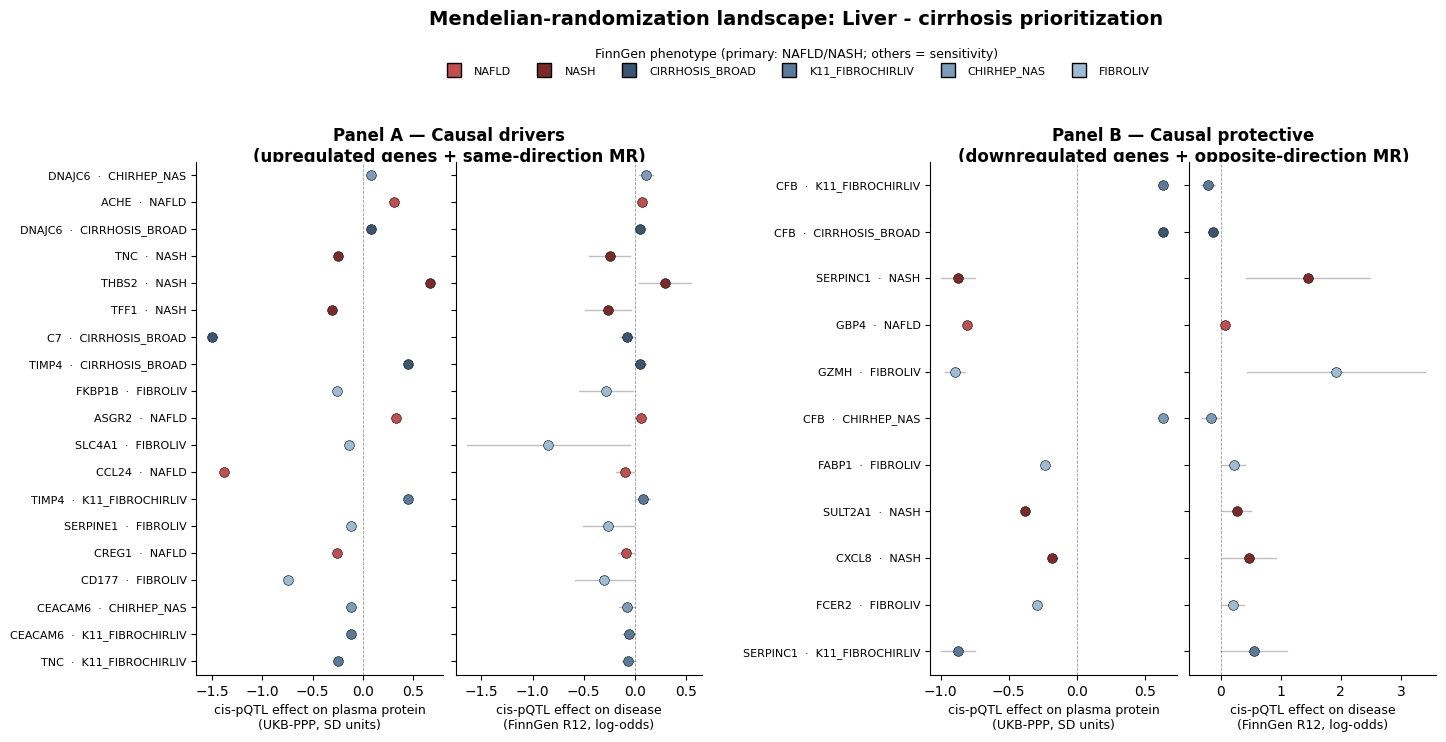

Saved: /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/TRACE/output/figures/figure_5.pdf
Panel A (drivers):    19 hits, 15 unique genes
Panel B (protective): 11 hits, 8 unique genes


In [27]:
import matplotlib.pyplot as plt
T = Config.TABLES_DIR

DRIVER_FILES  = ['mr_blood_cirrhosis_up100_same_direction.csv']   # liver-steatosis-UP only
PROTECT_FILES = ['mr_blood_cirr_down_opposite_direction.csv']  # liver-steatosis-DOWN only

_st9 = pd.read_excel(ST7_FILE, sheet_name='ST9', header=4)
_st9['gene_symbol'] = _st9['UKBPPP ProteinID'].astype(str).str.split(':').str[0]
SE_EXP_LOOKUP = (_st9[_st9['cis/trans'] == 'cis']
                 .drop_duplicates('gene_symbol')
                 .set_index('gene_symbol')['SE (discovery)'].to_dict())

def load_sig(files):
    rows = [pd.read_csv(T / n) for n in files]
    sig = pd.concat(rows, ignore_index=True)
    sig = sig[sig['p_MR'] < 0.05].copy()
    sig['SE_exp'] = sig['Gene'].map(SE_EXP_LOOKUP)
    return sig.sort_values('p_MR').reset_index(drop=True)

driver  = load_sig(DRIVER_FILES)
protect = load_sig(PROTECT_FILES)

phen_palette = {
    'NAFLD':            '#C04F4F',
    'NASH':             '#7C2929',
    'CIRRHOSIS_BROAD':  '#3A5670',
    'K11_FIBROCHIRLIV': '#5B7A99',
    'CHIRHEP_NAS':      '#7B9DBA',
    'FIBROLIV':         '#9DBCD3',
}

n_max = max(len(driver), len(protect), 1)
fig = plt.figure(figsize=(16, max(7, n_max * 0.32)))
outer = fig.add_gridspec(1, 2, wspace=0.45)

PANELS = [
    (driver,  'Panel A — Causal drivers\n(upregulated genes + same-direction MR)'),
    (protect, 'Panel B — Causal protective\n(downregulated genes + opposite-direction MR)'),
]

for panel_idx, (df, panel_title) in enumerate(PANELS):
    inner = outer[panel_idx].subgridspec(2, 2, height_ratios=[0.04, 1], hspace=0.02, wspace=0.05)
    title_ax = fig.add_subplot(inner[0, :]); title_ax.axis('off')
    title_ax.text(0.5, 0.5, panel_title, ha='center', va='center', fontsize=12, fontweight='bold')
    ax_exp = fig.add_subplot(inner[1, 0])
    ax_out = fig.add_subplot(inner[1, 1], sharey=ax_exp)

    df = df.iloc[::-1].reset_index(drop=True)
    y = np.arange(len(df))
    for i, row in df.iterrows():
        c = phen_palette.get(row['Phenotype'], 'gray')
        se_exp = row['SE_exp']
        if pd.notna(se_exp):
            ax_exp.plot([row['beta_exp']-1.96*se_exp, row['beta_exp']+1.96*se_exp],
                        [y[i], y[i]], color='gray', alpha=0.5, lw=1, zorder=1)
        ax_exp.plot(row['beta_exp'], y[i], 'o', color=c, markersize=7,
                    markeredgecolor='black', markeredgewidth=0.4, zorder=3)
        ax_out.plot([row['beta_out']-1.96*row['SE'], row['beta_out']+1.96*row['SE']],
                    [y[i], y[i]], color='gray', alpha=0.5, lw=1, zorder=1)
        ax_out.plot(row['beta_out'], y[i], 'o', color=c, markersize=7,
                    markeredgecolor='black', markeredgewidth=0.4, zorder=3)

    ax_exp.set_yticks(y)
    ax_exp.set_yticklabels([f'{r.Gene}  ·  {r.Phenotype}' for _, r in df.iterrows()], fontsize=8)
    ax_out.tick_params(axis='y', labelleft=False)
    for ax in (ax_exp, ax_out):
        ax.axvline(0, color='black', ls='--', lw=0.6, alpha=0.4)
        ax.spines[['top','right']].set_visible(False)
        ax.set_ylim(-0.5, len(df) - 0.5)
    ax_exp.set_xlabel('cis-pQTL effect on plasma protein\n(UKB-PPP, SD units)', fontsize=9)
    ax_out.set_xlabel('cis-pQTL effect on disease\n(FinnGen R12, log-odds)', fontsize=9)

phen_handles = [plt.Line2D([0],[0], marker='s', color='w', markerfacecolor=c, markersize=10,
                            markeredgecolor='black', label=p)
                for p, c in phen_palette.items()]
fig.legend(handles=phen_handles, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=6, frameon=False, title='FinnGen phenotype (primary: NAFLD/NASH; others = sensitivity)',
           fontsize=8, title_fontsize=9)
fig.suptitle('Mendelian-randomization landscape: Liver - cirrhosis prioritization', y=1.06, fontsize=14, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.95])
out_pdf = Config.FIGURES_DIR / 'figure_6.pdf'
fig.savefig(out_pdf, bbox_inches='tight')
fig.savefig(Config.FIGURES_DIR / 'figure_6.png', bbox_inches='tight', dpi=200)
plt.show()
print(f'Saved: {out_pdf}')
print(f'Panel A (drivers):    {len(driver)} hits, {driver.Gene.nunique()} unique genes')
print(f'Panel B (protective): {len(protect)} hits, {protect.Gene.nunique()} unique genes')